In [82]:
# Data manipulation
import pandas as pd
import numpy as np

# Data extraction
import kagglehub

import os
import sys
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Timing
import time

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import ClusterCentroids
from imblearn.combine import SMOTETomek

# Feature Extraction
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import shap

# Data manipulation
from sklearn.model_selection import StratifiedShuffleSplit

# Misc
import warnings
warnings.filterwarnings("ignore")

import ast

# Plot style
sns.set_theme(style="whitegrid")

# Reduction Experiment

In this file we aim to test our feature-importance results by evaluating 2 models, while only using their top-10 features:

- Random Forest baseline (uncahgned)
- Random Forest using Smote_Tomek

For each model, we will train and test the results using the top features from:

- Built-in feature importance
- Shap values
- Shap-Interaction-Global values (the values produced on all-samples)
- Shap-Interaction-Fraud-Specific values (the valued produced on Fraud samples)

---

## Load Transaction Data

In [83]:
# Download latest version if it doesn't exist yet
dataset_key = "mlg-ulb/creditcardfraud"
csv_name = "creditcardfraud.csv"

if not os.path.exists(csv_name):
    path = kagglehub.dataset_download(dataset_key)
else:
    path = csv_name

csv_files = glob.glob(path + "/**/*.csv", recursive=True)
print(csv_files)
df = pd.read_csv(csv_files[0])

target_col = "Class"

y = df[target_col].values
X = df.drop(columns=[target_col]).values

feature_names = df.drop(columns=[target_col]).columns.tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", len(feature_names))

['C:\\Users\\Daniel\\.cache\\kagglehub\\datasets\\mlg-ulb\\creditcardfraud\\versions\\3\\creditcard.csv']
X shape: (284807, 30)
y shape: (284807,)
Num features: 30


## Evaluation Method

Below we define the evaluation method, similar to the method used in main.ipynb

In [84]:
def evaluate_model(y_true, y_pred, y_proba=None):

    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }


    if y_proba is not None:

        results["roc_auc"] = roc_auc_score(
            y_true,
            y_proba
        )

        results["pr_auc"] = average_precision_score(
            y_true,
            y_proba
        )


    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()


    results.update({

        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp

    })


    return results

## Load Data

Below we'll load the data produced via running the experiment under the file "src/results_analysis/results_experiment1_3" section (3) and main's Q1_3 experiment.

In [85]:
features_df = pd.read_csv(
    "../out/Q1_3_features.csv",
    keep_default_na=False
)

shap_df = pd.read_csv(
    "../out/rf_shap_importance.csv"
)

interaction_df = pd.read_csv(
    "../out/rf_shap_interactions.csv"
)

Extract built-in feature importance for both model configurations

In [86]:
def extract_builtin_features(
    features_df,
    balancing
):

    row = features_df[
        (features_df["model"] == "Random Forest") &
        (features_df["balancing"] == balancing) &
        (features_df["class_weight"] == "None")
    ].iloc[0]


    importance_dict = ast.literal_eval(
        row["model_importance_top"]
    )


    importance_df = pd.DataFrame({

        "feature":
        list(
            importance_dict["feature"].values()
        ),

        "importance":
        list(
            importance_dict["importance"].values()
        )

    })


    return (
        importance_df
        .sort_values(
            "importance",
            ascending=False
        )
        .head(10)["feature"]
        .tolist()
    )

### Build Feature Sets

Below we'll build the feature sets for each of the configurations we'll run, as described at the top of this file.

**Note:** As for the pair-features, we examine the top-pairs until we locate up to 10 (if possible) unique features, which we then use for that configuration.

In [87]:
feature_sets = {}


def extract_top_interaction_features(
    interaction_df,
    config,
    interaction_type,
    n_features=10
):

    interactions = interaction_df[
        (interaction_df["configuration"] == config) &
        (interaction_df["interaction_type"] == interaction_type)
    ].sort_values(
        "interaction",
        ascending=False
    )


    selected_features = []


    # Add features from strongest interactions
    # until we reach the requested number of unique features

    for _, row in interactions.iterrows():

        for feature in [
            row["feature_1"],
            row["feature_2"]
        ]:

            if feature not in selected_features:

                selected_features.append(
                    feature
                )


            if len(selected_features) == n_features:
                break


        if len(selected_features) == n_features:
            break


    return selected_features



for config, balancing in [
    ("RF_Baseline", "None"),
    ("RF_SMOTE_Tomek", "SMOTE_Tomek")
]:

    feature_sets[config] = {}


    # -------------------------
    # Built-in importance
    # -------------------------

    feature_sets[config]["built_in"] = (
        extract_builtin_features(
            features_df,
            balancing
        )
    )


    # -------------------------
    # SHAP importance
    # -------------------------

    feature_sets[config]["shap"] = (
        shap_df[
            shap_df["configuration"] == config
        ]
        .sort_values(
            "shap_importance",
            ascending=False
        )
        .head(10)["feature"]
        .tolist()
    )


    # -------------------------
    # Global interactions
    # -------------------------

    feature_sets[config]["global_interaction"] = (
        extract_top_interaction_features(
            interaction_df,
            config,
            "interaction_global_mean",
            n_features=10
        )
    )


    # -------------------------
    # Fraud-specific interactions
    # -------------------------

    feature_sets[config]["fraud_interaction"] = (
        extract_top_interaction_features(
            interaction_df,
            config,
            "interaction_fraud_mean",
            n_features=10
        )
    )


feature_sets

{'RF_Baseline': {'built_in': ['V17',
   'V14',
   'V12',
   'V10',
   'V16',
   'V11',
   'V9',
   'V4',
   'V18',
   'V7'],
  'shap': ['V17', 'V14', 'V12', 'V10', 'V16', 'V11', 'V4', 'V9', 'V7', 'V26'],
  'global_interaction': ['V14', 'V17', 'V12', 'V10', 'V16', 'V11'],
  'fraud_interaction': ['V14', 'V17', 'V12', 'V10', 'V16', 'V11']},
 'RF_SMOTE_Tomek': {'built_in': ['V14',
   'V10',
   'V4',
   'V12',
   'V17',
   'V3',
   'V11',
   'V16',
   'V2',
   'V9'],
  'shap': ['V14', 'V4', 'V12', 'V10', 'V3', 'V17', 'V11', 'V16', 'V2', 'V1'],
  'global_interaction': ['V4', 'V14', 'V12', 'V10', 'V3', 'V11'],
  'fraud_interaction': ['V14', 'V17', 'V4', 'V10', 'V12', 'V16', 'V3']}}

In [88]:
def run_rf_feature_reduction_experiment(
    X,
    y,
    feature_names,
    feature_sets,
    output_path="../out/rf_feature_reduction_results.csv"
):

    results = []

    # ==========================================
    # Global split
    # ==========================================

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )


    X_train_df = pd.DataFrame(
        X_train,
        columns=feature_names
    )

    X_test_df = pd.DataFrame(
        X_test,
        columns=feature_names
    )


    configurations = {

        "RF_Baseline": None,

        "RF_SMOTE_Tomek": SMOTETomek(
            random_state=42
        )

    }


    # ==========================================
    # Run models
    # ==========================================

    for config_name, balancer in configurations.items():

        print("\n==============================")
        print(config_name)
        print("==============================")


        for method, selected_features in feature_sets[config_name].items():

            print(
                f"\nMethod: {method}"
            )


            selected_features = list(
                set(selected_features)
            )


            X_train_selected = (
                X_train_df[selected_features]
            )

            X_test_selected = (
                X_test_df[selected_features]
            )


            # -------------------------
            # Apply balancing
            # -------------------------

            if balancer is not None:

                X_train_bal, y_train_bal = (
                    balancer.fit_resample(
                        X_train_selected,
                        y_train
                    )
                )

            else:

                X_train_bal = X_train_selected
                y_train_bal = y_train


            print(
                f"Using {len(selected_features)} features"
            )


            # -------------------------
            # Train RF
            # -------------------------

            rf = RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )


            rf.fit(
                X_train_bal,
                y_train_bal
            )


            # -------------------------
            # Predict
            # -------------------------

            y_pred = rf.predict(
                X_test_selected
            )

            y_proba = rf.predict_proba(
                X_test_selected
            )[:,1]


            # -------------------------
            # Evaluate
            # -------------------------

            metrics = evaluate_model(
                y_test,
                y_pred,
                y_proba
            )


            results.append({

                "configuration": config_name,

                "feature_method": method,

                "num_features": len(selected_features),

                "features": ",".join(
                    selected_features
                ),

                **metrics

            })


    # ==========================================
    # Save results
    # ==========================================

    results_df = pd.DataFrame(results)

    results_df.to_csv(
        output_path,
        index=False
    )

    print(
        f"\nSaved results to: {output_path}"
    )


    return results_df

In [89]:
"""
rf_reduction_results = run_rf_feature_reduction_experiment(
    X,
    y,
    feature_names,
    feature_sets
)


rf_reduction_results
"""

'\nrf_reduction_results = run_rf_feature_reduction_experiment(\n    X,\n    y,\n    feature_names,\n    feature_sets\n)\n\n\nrf_reduction_results\n'

----

# Results Review

We aim to answer the following questions:

1. Did feature reduction hurt performance?
2. Which feature selection method preserves performance best?
3. How did SMOTE-Tomek affect the results?

Load the result's data

In [90]:
# ==========================================
# Feature reduction experiment results
# ==========================================

reduction_results = pd.read_csv(
    "../out/rf_feature_reduction_results.csv",
    keep_default_na=False
)


reduction_results[
    [
        "configuration",
        "feature_method",
        "num_features",
        "pr_auc",
        "roc_auc",
        "recall",
        "precision",
        "f1"
    ]
].sort_values(
    [
        "configuration",
        "recall"
    ],
    ascending=False
)

,configuration,feature_method,num_features,pr_auc,roc_auc,recall,precision,f1
4,RF_SMOTE_Tomek,built_in,10,0.838186,0.964405,0.836735,0.713043,0.769953
5,RF_SMOTE_Tomek,shap,10,0.847545,0.964906,0.836735,0.725664,0.777251
6,RF_SMOTE_Tomek,global_interaction,6,0.797811,0.973311,0.836735,0.546667,0.661290
7,RF_SMOTE_Tomek,fraud_interaction,7,0.833745,0.953686,0.836735,0.602941,0.700855
2,RF_Baseline,global_interaction,6,0.855750,0.937556,0.836735,0.942529,0.886486
3,RF_Baseline,fraud_interaction,6,0.855750,0.937556,0.836735,0.942529,0.886486
0,RF_Baseline,built_in,10,0.845502,0.952837,0.826531,0.941860,0.880435
1,RF_Baseline,shap,10,0.847731,0.952943,0.816327,0.952381,0.879121


Load original results data (before reduction)

In [91]:
current_path = Path.cwd()

while current_path.name != "FinalProject":
    current_path = current_path.parent


PROJECT_ROOT = current_path


# ==========================================
# Original Random Forest results
# ==========================================

original_results = pd.read_csv(
    PROJECT_ROOT / "out" / "Q1_3_output.csv",
    keep_default_na=False
)


rf_results = original_results[
    (original_results["model"] == "Random Forest") &
    (original_results["class_weight"] == "None") &
    (original_results["threshold_mode"] == "default") &
    (
        original_results["balancing"].isin(
            ["None", "SMOTE_Tomek"]
        )
    )
]


rf_results.head()



,model,balancing,class_weight,threshold_mode,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
40,Random Forest,None,None,default,0.999596,0.941176,0.816327,0.874317,0.963027,0.873391,56859,5,18,80
52,Random Forest,SMOTE_Tomek,None,default,0.999456,0.831683,0.857143,0.844221,0.969262,0.873052,56847,17,14,84


Organize the table for comparison

In [92]:
# ==========================================
# Prepare full-feature Random Forest results
# ==========================================

# Select relevant metrics from original RF experiment
rf_comparison = rf_results[
    [
        "balancing",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "false_positives",
        "false_negatives"
    ]
].copy()


# Rename columns for consistency
rf_comparison = rf_comparison.rename(
    columns={
        "balancing": "configuration",
        "false_positives": "FP",
        "false_negatives": "FN"
    }
)


# Convert configuration names
rf_comparison["configuration"] = (
    rf_comparison["configuration"]
    .replace(
        {
            "None": "RF Baseline",
            "SMOTE_Tomek": "RF SMOTE-Tomek"
        }
    )
)


# Mark these as using all features
rf_comparison["feature_selection"] = "All Features"



# ==========================================
# Prepare feature-reduced Random Forest results
# ==========================================

# Use feature reduction experiment results
reduction_comparison = reduction_results.copy()


# Rename feature method column
reduction_comparison = reduction_comparison.rename(
    columns={
        "feature_method": "feature_selection"
    }
)


# Convert configuration names if needed
reduction_comparison["configuration"] = (
    reduction_comparison["configuration"]
    .replace(
        {
            "None": "RF Baseline",
            "SMOTE_Tomek": "RF SMOTE-Tomek"
        }
    )
)


# Keep relevant metrics
reduction_comparison = reduction_comparison[
    [
        "configuration",
        "feature_selection",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc"
    ]
]


# Add placeholders for unavailable confusion matrix values
reduction_comparison["FP"] = None
reduction_comparison["FN"] = None



# ==========================================
# Combine both experiment types
# ==========================================

performance_df = pd.concat(
    [
        rf_comparison,
        reduction_comparison
    ],
    ignore_index=True
)


# Rename methods for readable graphs/tables
performance_df["feature_selection"] = (
    performance_df["feature_selection"]
    .replace(
        {
            "built_in": "Built-in Importance",
            "shap": "SHAP",
            "global_interaction": "Global Interaction",
            "fraud_interaction": "Fraud Interaction"
        }
    )
)


# Display final comparison table
performance_df.sort_values(
    [
        "configuration",
        "feature_selection"
    ]
)

,configuration,precision,recall,f1,roc_auc,pr_auc,FP,FN,feature_selection
0,RF Baseline,0.941176,0.816327,0.874317,0.963027,0.873391,5,18,All Features
1,RF SMOTE-Tomek,0.831683,0.857143,0.844221,0.969262,0.873052,17,14,All Features
2,RF_Baseline,0.941860,0.826531,0.880435,0.952837,0.845502,None,None,Built-in Importance
5,RF_Baseline,0.942529,0.836735,0.886486,0.937556,0.855750,None,None,Fraud Interaction
4,RF_Baseline,0.942529,0.836735,0.886486,0.937556,0.855750,None,None,Global Interaction
3,RF_Baseline,0.952381,0.816327,0.879121,0.952943,0.847731,None,None,SHAP
6,RF_SMOTE_Tomek,0.713043,0.836735,0.769953,0.964405,0.838186,None,None,Built-in Importance
9,RF_SMOTE_Tomek,0.602941,0.836735,0.700855,0.953686,0.833745,None,None,Fraud Interaction
8,RF_SMOTE_Tomek,0.546667,0.836735,0.661290,0.973311,0.797811,None,None,Global Interaction
7,RF_SMOTE_Tomek,0.725664,0.836735,0.777251,0.964906,0.847545,None,None,SHAP


--- 

# Results Analysis

Below we'll examine the results and interpret the meaning

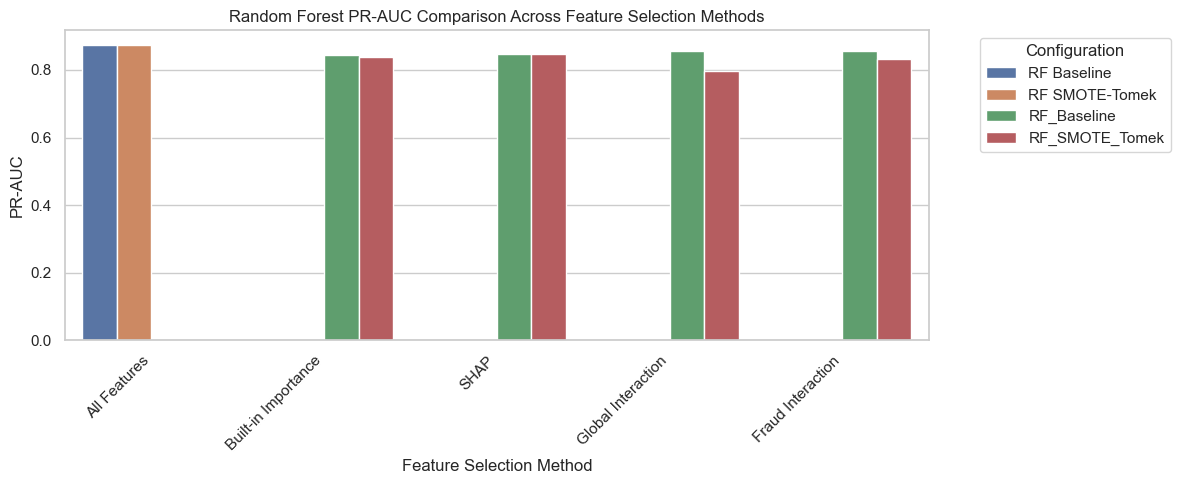

In [96]:
plt.figure(figsize=(12,5))


sns.barplot(
    data=performance_df,
    x="feature_selection",
    y="pr_auc",
    hue="configuration"
)


plt.title(
    "Random Forest PR-AUC Comparison Across Feature Selection Methods"
)

plt.xlabel(
    "Feature Selection Method"
)

plt.ylabel(
    "PR-AUC"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Configuration",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

## Interpretation:

Feature reduction slightly decreases PR-AUC compared to using all features, but the reduction is relatively small. This indicates that the selected feature subsets preserve most of the model's ability to distinguish fraudulent transactions while using fewer features.

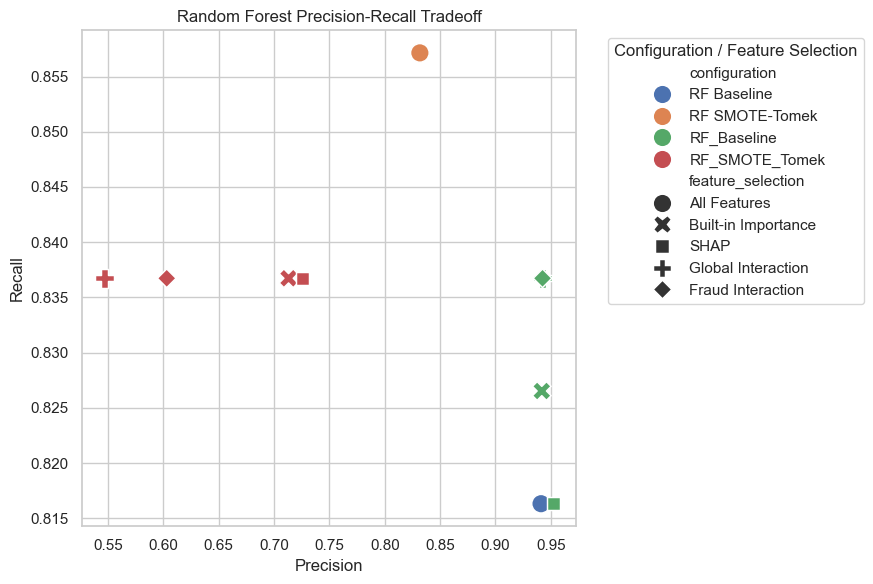

In [102]:
plt.figure(figsize=(9,6))


sns.scatterplot(
    data=performance_df,
    x="precision",
    y="recall",
    hue="configuration",
    style="feature_selection",
    s=180
)


plt.title(
    "Random Forest Precision-Recall Tradeoff"
)

plt.xlabel(
    "Precision"
)

plt.ylabel(
    "Recall"
)


plt.grid(
    True
)


# Place legend outside graph
plt.legend(
    title="Configuration / Feature Selection",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.tight_layout()

plt.show()

## Interpretation:

Despite using fewer features, some of the feature reduction managed to maintain a reasonable score.

We can note that the Baseline RF (🟢green symbols) maintained their precision while varying in recall during reduction.

While the Smote-Tomek modfified RF (🔴red symbols) maintained their recall while varying in precsiion during reduction.

The best performing configuration was Baseline RF with Fraud-Specific reduction.

---

# Final Conclusions:

While feature reduction casued some decline in scores, certain configurations maintained a reasonable score.

However, given that Fraud-detection and avoidance of False-Negatives (ie; misclassing fraud cases) is valued highly in this project, we deduce that the scores are insufficient.
That is due to the fact that none of the reduced-configurations managed to score above 85% recall.

**Note:** We only used 10 important features for built-in and Shap-importance, while using only 6~ importance features during Shap-Interaction (due to how we calculated the interactions scores, to avoid increasing runtime). Therefore it might be possible we missed important feature interactions that may cause the scores to be sufficient for reduction. 